### Imports

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import kagglehub


### Step 1: Download ORL Dataset

In [274]:
# Download latest version
path = kagglehub.dataset_download("kasikrit/att-database-of-faces")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\Kimo Store\.cache\kagglehub\datasets\kasikrit\att-database-of-faces\versions\2


### Step 2: Generate the Data Matrix and the Label vector

In the AT&T Face Dataset, a subject refers to a person. The dataset includes 40 different people, and each one is stored in a separate folder
Reading all 400 images (10 per person × 40 people)
Storing them in images (shape: 400, 112, 92)
Assigning a label (person ID) from 1 to 40 to each image

In [275]:
images = [] # data matrix
Y = []  # label vector

# Loop through subjects (s1 to s40)
for subject_id in range(1, 41): 
    subject_folder = os.path.join(path, f's{subject_id}')
    
    # Loop through each of the 10 images for the subject
    for img_number in range(1, 11):  # 1.pgm to 10.pgm
        img_path = os.path.join(subject_folder, f'{img_number}.pgm')
        
        # Read image 
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # Append image and label
        images.append(img)
        Y.append(subject_id)  # Use subject_id as the label

images = np.array(images)        
Y = np.array(Y) 
D = images.reshape(400, -1)
D.shape

print("Loaded dataset shape:", D.shape)
print("Y shape:", Y.shape)


Loaded dataset shape: (400, 10304)
Y shape: (400,)


### Step 3: Split the Dataset into Training and Test sets

In [276]:
# Select training and testing rows
D_train = D[::2]  # odd-numbered rows
D_test  = D[1::2] # even-numbered rows 

y_train = Y[::2]
y_test  = Y[1::2]

print("Training set shape:", D_train.shape)
print("Testing set shape:", D_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)
print(y_train.max(), y_train.min())

Training set shape: (200, 10304)
Testing set shape: (200, 10304)
Training labels shape: (200,)
Testing labels shape: (200,)
40 1


### PCA Implementation

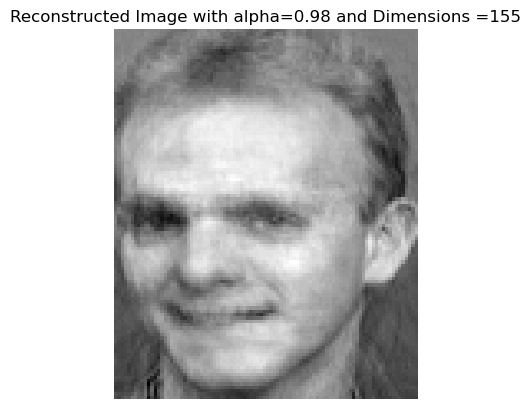

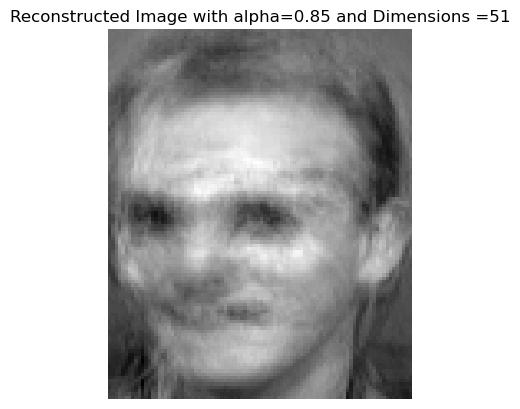

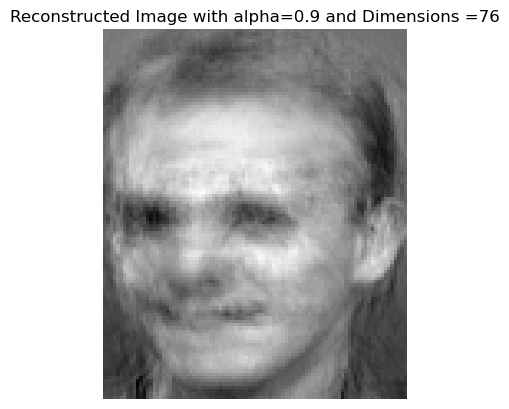

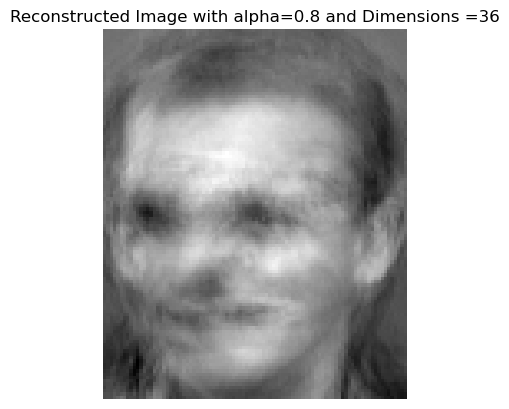

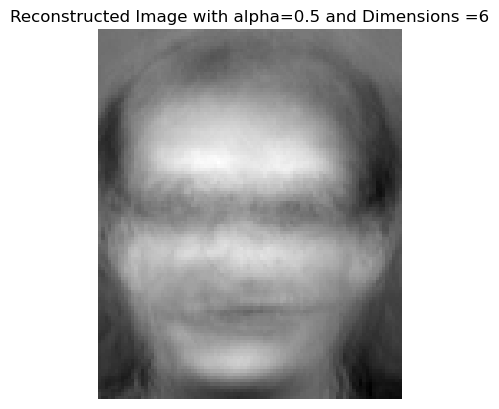

In [277]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.offsetbox as offsetbox

class PCA:
    def __init__(self, D_train, D_test, y_train, y_test):
        """Class intialization"""
        self.D_train = D_train
        self.D_test = D_test
        self.y_train = y_train
        self.y_test = y_test
        self.D_centered = []
        self.eigenvalues = []
        self.eigenvectors = []

    def compCov(self):
        """Compute the covariance matrix"""
        mean_face = np.mean(self.D_train, axis=0)
        self.D_centered = self.D_train - mean_face
        Cov = self.D_centered @ self.D_centered.T
        Cov = Cov / self.D_train.shape[0]
        return Cov

    def compEig(self, Cov):
        """Compute the eigenvalues and the eigenvectors in feature space"""
        eigenvalues, eigenvectors = np.linalg.eigh(Cov)
        eigenvalues = eigenvalues[::-1]
        eigenvectors = eigenvectors[:, ::-1]

        # Convert to feature space
        eigvecs_feat_space = self.D_centered.T @ eigenvectors 
        eigvecs_feat_space = eigvecs_feat_space[:, :len(eigenvalues)]  # reduce to same k

        norm_eigenvect = eigvecs_feat_space / np.linalg.norm(eigvecs_feat_space, axis=0)

        self.eigenvalues = eigenvalues
        self.eigenvectors = norm_eigenvect


    def selectComp(self, alpha):
        """Select the first i eigenvectors based on the explained variance"""
        sum = 0
        eigsum = np.sum(self.eigenvalues)
        for i, val in enumerate(self.eigenvalues):
            sum += val
            if sum / eigsum >= alpha:
                return self.eigenvectors[:, :i+1]

    def project(self, alpha):
        """Project the data on the eigenvectors"""
        Cov = self.compCov()
        self.compEig(Cov)
        eigvec = self.selectComp(alpha)
        proj = self.D_centered @ eigvec
        return proj , eigvec

    def visualize_projection(self, alpha, image_shape=(112, 92)):
        """Image reconstruction"""
        projected , subeigvec = self.project(alpha)
        recon = projected[22] @ subeigvec.T
        mean_face = np.mean(self.D_train, axis=0)
        recon_image = recon + mean_face
        recon_image = recon_image.reshape(image_shape)

        plt.imshow(recon_image, cmap='gray')
        plt.title(f"Reconstructed Image with alpha={alpha} and Dimensions ={projected.shape[1]}")
        plt.axis('off')
        plt.show()


pca = PCA(D_train, D_test, y_train, y_test)
pca.visualize_projection(alpha=0.98)
pca.visualize_projection(alpha=0.85)
pca.visualize_projection(alpha=0.9)
pca.visualize_projection(alpha=0.8)
pca.visualize_projection(alpha=0.5)


## Unsupervised Clustering
### K-Means Clustering

In [278]:
class KMeans:
    def __init__(self, n_clusters, max_iter=100):
        """Class initialization"""
        self.n_clusters = n_clusters
        self.max_iter = max_iter

    def fit(self, X):
        """Fit the KMeans model to the data"""
        # Randomly initialize centroids
        np.random.seed(42)
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)  # Randomly select initial centroids
        self.centroids = X[indices]
        
        for _ in range(self.max_iter):
            # Compute distances from each point to each centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1) + 1  # Shift labels to start from 1
            
            new_centroids = np.array([
                X[self.labels_ == i].mean(axis=0) if np.any(self.labels_ == i) else self.centroids[i - 1]
                for i in range(1, self.n_clusters + 1)
            ])
            
            # Check for convergence
            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids
            
            # print("Updated centroids:\n", self.centroids)
            # print("Updated labels:\n", self.labels_)
            # print("Updated centroids shape:", self.centroids.shape)
            # print("Updated labels shape:", self.labels_.shape)
            

    def predict(self, X):
        """Predict the closest cluster each sample in X belongs to"""
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1) + 1  # Shift labels to start from 1


### K-Means Clustering Evaluation

In [279]:
from sklearn.metrics import confusion_matrix, f1_score
from scipy.optimize import linear_sum_assignment

def clustering_accuracy(y_true, y_pred):
    """Compute clustering accuracy using the Hungarian algorithm"""
    D = max(y_pred.max(), y_true.max()) + 1 # Number of clusters
    # print("Number of clusters:", D)
    # Initialize the cost matrix
    cost = np.zeros((D, D), dtype=int)
    
    # Count the number of points assigned to each cluster
    for i in range(len(y_pred)):
        cost[y_pred[i], y_true[i]] += 1
        
    row_ind, col_ind = linear_sum_assignment(cost.max() - cost)
    total_correct = sum(cost[i, j] for i, j in zip(row_ind, col_ind))   # 
    
    # print("Cost matrix:\n", cost)
    # print("Cost matrix shape:", cost.shape)
    # print("Row indices:", row_ind)
    # print("Column indices:", col_ind)
    # print("Total correct assignments:", total_correct)
    # print("---------------------------------------------------------")
    return total_correct / len(y_pred)


### Run K-Means for different alpha and K

In [280]:
results = []

for alpha in [0.8, 0.85, 0.9, 0.95]:
    reduced_data, eigvecs = pca.project(alpha)

    for K in [20, 40, 60]:
        kmeans = KMeans(n_clusters=K)
        kmeans.fit(reduced_data)

        acc = clustering_accuracy(pca.y_train, kmeans.labels_)
        results.append((alpha, K, acc))
        print(f"Alpha: {alpha}, K: {K}, Accuracy: {acc:.4f}")
    print("--------------------------------------")



Alpha: 0.8, K: 20, Accuracy: 0.4050
Alpha: 0.8, K: 40, Accuracy: 0.6700
Alpha: 0.8, K: 60, Accuracy: 0.6700
--------------------------------------
Alpha: 0.85, K: 20, Accuracy: 0.4050
Alpha: 0.85, K: 40, Accuracy: 0.6600
Alpha: 0.85, K: 60, Accuracy: 0.6850
--------------------------------------
Alpha: 0.9, K: 20, Accuracy: 0.4050
Alpha: 0.9, K: 40, Accuracy: 0.6450
Alpha: 0.9, K: 60, Accuracy: 0.6450
--------------------------------------
Alpha: 0.95, K: 20, Accuracy: 0.3950
Alpha: 0.95, K: 40, Accuracy: 0.6450
Alpha: 0.95, K: 60, Accuracy: 0.6450
--------------------------------------


###  Plot Accuracy vs K and Alpha

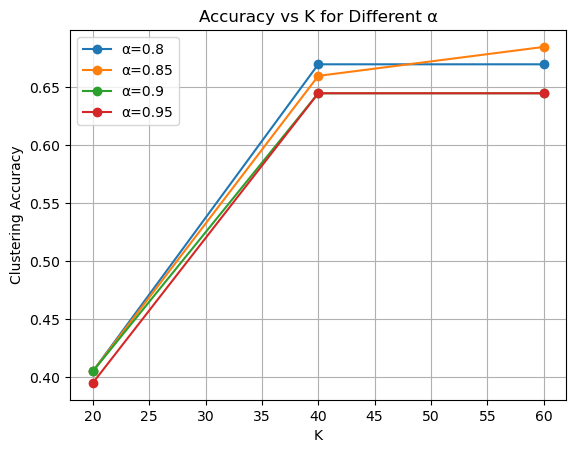

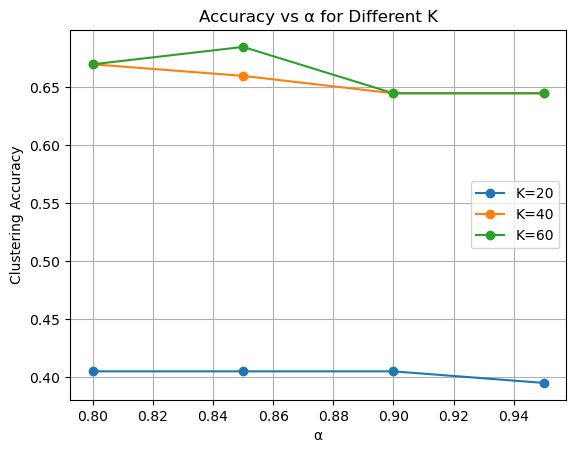

In [281]:
import matplotlib.pyplot as plt

for alpha in [0.8, 0.85, 0.9, 0.95]:
    accs = [acc for a, k, acc in results if a == alpha]
    ks = [k for a, k, acc in results if a == alpha]
    plt.plot(ks, accs, marker='o', label=f'α={alpha}')

plt.xlabel('K')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs K for Different α')
plt.legend()
plt.grid()
plt.show()

for k in [20, 40, 60]:
    accs = [acc for a, k_val, acc in results if k_val == k]
    alphas = [a for a, k_val, acc in results if k_val == k]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
    

plt.xlabel('α')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs α for Different K')  
plt.legend()
plt.grid()
plt.show()


### Evaluate Best Model on Test Set

Best alpha: 0.85, Best K: 60, Accuracy: 0.6850
Test Accuracy: 0.7400
Test F1 Score: 0.0188


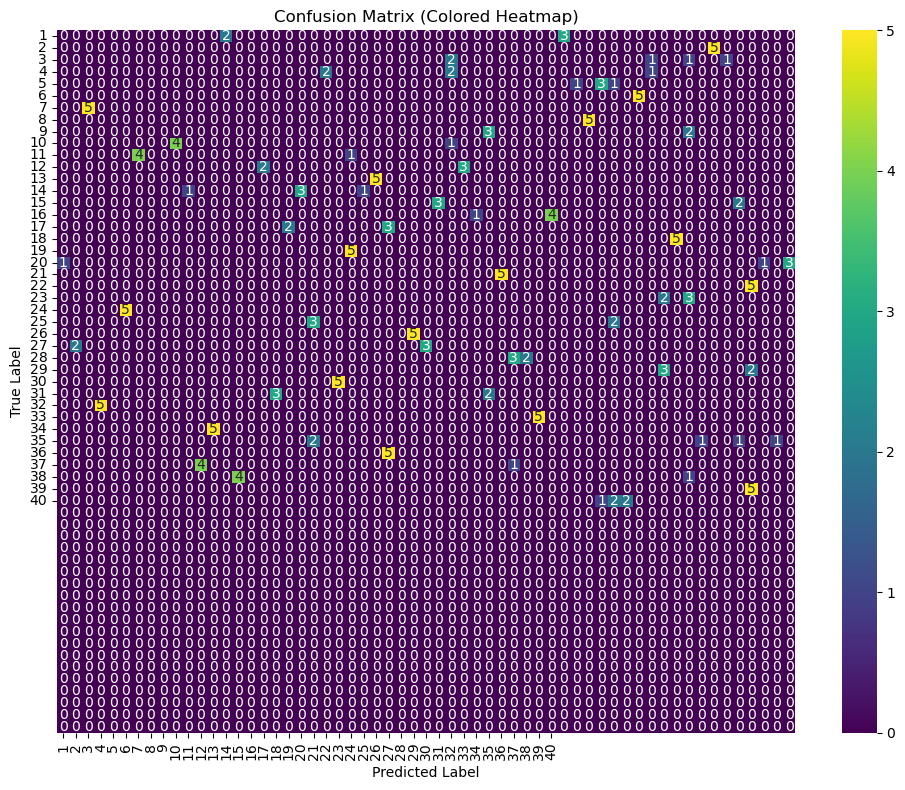

Confusion Matrix:
    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
0    0   0   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
1    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   5   0   0   0   0   0   0
2    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   1   0   0   1   0   0   0   0   0
3    0   0   0   0   0   0

In [285]:
# Find the entry with the highest accuracy
best_alpha, best_K, best_acc = max(results, key=lambda x: x[2])

print(f"Best alpha: {best_alpha}, Best K: {best_K}, Accuracy: {best_acc:.4f}")

# Get the PCA eigenvectors for best_alpha
_, eigvecs = pca.project(best_alpha)
mean_face = np.mean(pca.D_train, axis=0)
D_test_centered = pca.D_test - mean_face
test_proj = D_test_centered @ eigvecs

# Fit KMeans on train set (projected)
train_proj, _ = pca.project(best_alpha)
kmeans_best = KMeans(n_clusters=best_K)
kmeans_best.fit(train_proj)

# Predict on test set
y_pred_test = kmeans_best.predict(test_proj)

# Evaluate clustering accuracy
acc = clustering_accuracy(pca.y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")

# F1 and Confusion Matrix
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

f1 = f1_score(pca.y_test, y_pred_test, average='macro')
print(f"Test F1 Score: {f1:.4f}")

# Compute confusion matrix (just to be sure)
cm = confusion_matrix(pca.y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=True, 
            xticklabels=np.unique(pca.y_test), 
            yticklabels=np.unique(pca.y_test))
plt.title("Confusion Matrix (Colored Heatmap)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
df = pd.DataFrame(cm)
print(df.to_string())



### Gaussian Mixture Model Clustering

### Gaussian Mixture Model Clustering Evaluation

### Bonus